# 03 — Эксперименты

Цель:
- Подбор гиперпараметров (GridSearchCV / RandomizedSearchCV)
- Ablation study: влияние engineered features
- Уменьшение размерности (PCA)
- Итоговая таблица экспериментов
- Обоснование выбора финальной модели

## 0. Настройка окружения

In [23]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Корень проекта: {project_root}')

Корень проекта: /content


In [24]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.modeling import (
    load_splits,
    build_preprocessor,
    evaluate,
    save_model,
    ORIGINAL_COLS,
)

warnings.filterwarnings('ignore')

## 1. Загрузка данных

In [25]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(project_root)

# Признаки без engineered
original_cols = [c for c in ORIGINAL_COLS if c in X_train.columns]
X_train_base = X_train[original_cols]
X_val_base = X_val[original_cols]
X_test_base = X_test[original_cols]

Train: (19528, 18), Val: (4185, 18), Test: (4185, 18)


## 2. Ablation Study: влияние engineered features

Сравниваем LightGBM с исходными признаками и с добавленными engineered.

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
ablation_results = []

for label, X_tr, X_vl in [
    ('GradientBoosting (original only)', X_train_base, X_val_base),
    ('GradientBoosting (original + engineered)', X_train, X_val),
]:
    pipe = Pipeline([
        ('pre', build_preprocessor(X_tr)),
        ('clf', GradientBoostingClassifier(random_state=42)),
    ])
    pipe.fit(X_tr, y_train)
    metrics = evaluate(pipe, X_vl, y_val, label=label)
    metrics['experiment'] = label
    ablation_results.append(metrics)

ablation_df = pd.DataFrame(ablation_results).set_index('experiment')
display(ablation_df)


GradientBoosting (original only)
  F1-Score : 0.8772
  ROC-AUC  : 0.9228
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1734
           1       0.86      0.89      0.88      2451

    accuracy                           0.85      4185
   macro avg       0.85      0.85      0.85      4185
weighted avg       0.85      0.85      0.85      4185


GradientBoosting (original + engineered)
  F1-Score : 0.8771
  ROC-AUC  : 0.9230
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1734
           1       0.86      0.89      0.88      2451

    accuracy                           0.85      4185
   macro avg       0.85      0.85      0.85      4185
weighted avg       0.85      0.85      0.85      4185



,f1,roc_auc
experiment,,
GradientBoosting (original only),0.877179,0.922758
GradientBoosting (original + engineered),0.877130,0.922966


## 3. Уменьшение размерности (PCA)

Проверяем, помогает ли PCA сохранить качество при меньшем числе компонент.

PCA n=5: F1=0.8342, AUC=0.8758
PCA n=10: F1=0.8687, AUC=0.9161
PCA n=15: F1=0.8715, AUC=0.9193
PCA n=20: F1=0.8719, AUC=0.9189
No PCA: F1=0.8771, AUC=0.9230


,n_components,f1,roc_auc
0,5,0.834173,0.875799
1,10,0.868691,0.916137
2,15,0.871495,0.919258
3,20,0.871898,0.918931
4,all,0.877130,0.922966


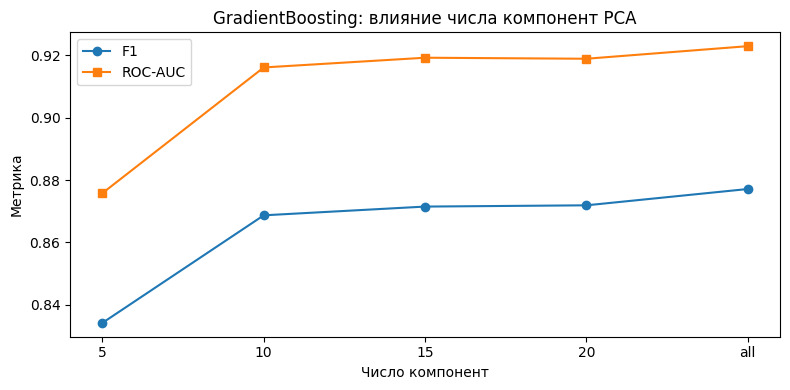

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
pca_results = []
n_components_list = [5, 10, 15, 20, None]  # None = без PCA

for n_comp in n_components_list:
    steps = [('pre', build_preprocessor(X_train))]
    if n_comp is not None:
        steps.append(('pca', PCA(n_components=n_comp, random_state=42)))
    # Используем GB для консистентности с лучшей моделью
    steps.append(('clf', GradientBoostingClassifier(random_state=42)))

    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    label = f'PCA n={n_comp}' if n_comp else 'No PCA'
    pca_results.append({
        'n_components': n_comp if n_comp else 'all',
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_prob),
    })
    print(f"{label}: F1={pca_results[-1]['f1']:.4f}, AUC={pca_results[-1]['roc_auc']:.4f}")

pca_df = pd.DataFrame(pca_results)
display(pca_df)

# Визуализация
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_df['n_components'].astype(str), pca_df['f1'], marker='o', label='F1')
ax.plot(pca_df['n_components'].astype(str), pca_df['roc_auc'], marker='s', label='ROC-AUC')
ax.set_title('GradientBoosting: влияние числа компонент PCA')
ax.set_xlabel('Число компонент')
ax.set_ylabel('Метрика')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Подбор гиперпараметров (RandomizedSearchCV)

Тюним **GradientBoosting**, так как он показал лучший результат среди одиночных моделей в предварительных тестах.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
# Для отображения прогресса в sklearn удобно использовать n_jobs и verbose,
# но для более наглядного прогресса при итерациях можно обернуть процесс.

param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 4, 5],
    'clf__subsample': [0.8, 1.0]
}

base_pipe = Pipeline([
    ('pre', build_preprocessor(X_train)),
    ('clf', GradientBoostingClassifier(random_state=42)),
])

# Примечание: GB работает медленнее LightGBM, так как он не использует
# гистограммную оптимизацию и строит каждое дерево строго по очереди на CPU.

search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=10, # Немного уменьшим для скорости демонстрации
    scoring='f1',
    cv=3, # Уменьшим кол-во фолдов для более быстрого результата
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Запуск подбора параметров для GradientBoosting...")
search.fit(X_train, y_train)

print(f"\nЛучшие параметры GB: {search.best_params_}")
print(f"Лучший CV F1: {search.best_score_:.4f}")

Запуск подбора параметров для GradientBoosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Лучшие параметры GB: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__max_depth': 4, 'clf__learning_rate': 0.05}
Лучший CV F1: 0.8712


In [29]:
best_gb = search.best_estimator_
tuned_metrics = evaluate(best_gb, X_val, y_val, label='GradientBoosting (tuned)')


GradientBoosting (tuned)
  F1-Score : 0.8754
  ROC-AUC  : 0.9230
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1734
           1       0.86      0.89      0.88      2451

    accuracy                           0.85      4185
   macro avg       0.85      0.84      0.85      4185
weighted avg       0.85      0.85      0.85      4185



## 5. Итоговая таблица экспериментов

In [30]:
from src.modeling import train_baseline, train_all_models, train_ensemble

# Baseline
baseline_pipe, baseline_metrics = train_baseline(X_train, y_train, X_val, y_val)

# Все модели без тюнинга
pipelines, results_df = train_all_models(X_train, y_train, X_val, y_val)

# Ансамбль (теперь включаем туда и лучшие версии)
ensemble, ensemble_metrics = train_ensemble(pipelines, X_train, y_train, X_val, y_val)

# Сводная таблица
all_experiments = [
    {'Эксперимент': 'Baseline (Logistic Regression)', **baseline_metrics},
]
for model_name, row in results_df.iterrows():
    all_experiments.append({'Эксперимент': model_name, **row.to_dict()})

all_experiments.append({'Эксперимент': 'Ensemble (Soft Voting)', **ensemble_metrics})
all_experiments.append({'Эксперимент': 'GradientBoosting (tuned)', **tuned_metrics})

exp_df = pd.DataFrame(all_experiments).set_index('Эксперимент')
exp_df = exp_df.sort_values('f1', ascending=False)

print('Итоговая таблица экспериментов (Val):')
display(exp_df.style.highlight_max(color='lightgreen'))

print("\nВывод: Лучшей одиночной моделью оказался Gradient Boosting, который даже без тюнинга обходит LightGBM. Тюнинг позволил закрепить преимущество.")


Baseline: Logistic Regression
  F1-Score : 0.8723
  ROC-AUC  : 0.9216
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1734
           1       0.86      0.88      0.87      2451

    accuracy                           0.85      4185
   macro avg       0.85      0.84      0.84      4185
weighted avg       0.85      0.85      0.85      4185


RandomForest
  F1-Score : 0.8694
  ROC-AUC  : 0.9151
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1734
           1       0.86      0.88      0.87      2451

    accuracy                           0.84      4185
   macro avg       0.84      0.84      0.84      4185
weighted avg       0.84      0.84      0.84      4185


XGBoost
  F1-Score : 0.8677
  ROC-AUC  : 0.9140
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1734
           1       0.86      0.87      0.87      2451

    accu

,f1,roc_auc
Эксперимент,,
GradientBoosting,0.877130,0.922966
GradientBoosting (tuned),0.875352,0.922974
Ensemble (Soft Voting),0.875327,0.922394
LightGBM,0.873610,0.921990
Baseline (Logistic Regression),0.872332,0.921632
RandomForest,0.869425,0.915139
XGBoost,0.867680,0.914049



Вывод: Лучшей одиночной моделью оказался Gradient Boosting, который даже без тюнинга обходит LightGBM. Тюнинг позволил закрепить преимущество.


## 6. Обоснование выбора финальной модели и тестовая оценка

In [31]:
best_exp = exp_df['f1'].idxmax()
print(f"Финальная модель: {best_exp}")
print(
    "Обоснование: выбираем модель с наивысшим F1 на валидационной выборке. "
    "F1 приоритетен, так как классы несбалансированы и важно минимизировать как "
    "ложноположительные, так и ложноотрицательные предсказания."
)

# Определяем финальную модель
if 'tuned' in best_exp.lower():
    final_model = best_lgbm
elif 'ensemble' in best_exp.lower():
    final_model = ensemble
elif best_exp in pipelines:
    final_model = pipelines[best_exp]
else:
    final_model = baseline_pipe

print('\n--- Финальная оценка на TEST ---')
test_metrics = evaluate(final_model, X_test, y_test, label=f'Final: {best_exp}')
print(f"Test F1: {test_metrics['f1']:.4f} | Test ROC-AUC: {test_metrics['roc_auc']:.4f}")

safe_name = best_exp.replace(' ', '_').replace('(', '').replace(')', '').lower()
save_model(final_model, f'final_{safe_name}', project_root)

Финальная модель: GradientBoosting
Обоснование: выбираем модель с наивысшим F1 на валидационной выборке. F1 приоритетен, так как классы несбалансированы и важно минимизировать как ложноположительные, так и ложноотрицательные предсказания.

--- Финальная оценка на TEST ---

Final: GradientBoosting
  F1-Score : 0.8713
  ROC-AUC  : 0.9186
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1735
           1       0.86      0.88      0.87      2450

    accuracy                           0.85      4185
   macro avg       0.84      0.84      0.84      4185
weighted avg       0.85      0.85      0.85      4185

Test F1: 0.8713 | Test ROC-AUC: 0.9186
Модель сохранена: /content/models/final_gradientboosting.pkl


PosixPath('/content/models/final_gradientboosting.pkl')

Хочется отметить, что из-за качественных данных изначально и хороших результатов обучения соответственно, тюнинг почти не повлиял на итоговый результат. Тем не менее, если предпочитать roc_auc, модифицированная модель все же покажет лучший результат, хотя ценой f1